# PCA & Dimensionality Reduction Analysis
## London Urban Safety Classification

This notebook implements a complete dimensionality reduction analysis for the 4 features in your urban safety model:
- lighting, visibility, connectivity, enclosure

**Steps:**
1. Load & explore features
2. Correlation analysis
3. Standardize features
4. Apply PCA (all components)
5. Interpret loadings & variance
6. Make reduction decision
7. Compare model performance (original vs. reduced)


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

# Set visualization defaults
sns.set_style('darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.float_format', '{:.4f}'.format)

print('✓ All imports successful')

✓ All imports successful


## Step 1: Load & Prepare Data

**Data source:** `segment_risk_scores_w-id.csv` 
- Features: lighting, visibility, connectivity, enclosure, transport proximity, land-use (all normalized)
- Target: risk_class (3 classes: 'low', 'medium', 'high')
- Includes borough and location_id for reference


In [48]:
# ====================================================================================
# Load features with updated 4-class safety classification
# ====================================================================================

print('Loading feature data...')

# Define feature columns
FEATURE_COLS = ['lighting_norm', 'visibility_norm', 'connectivity_norm', 'enclosure_norm', 'dominant_land_use_score_norm', 'public_transport_proximity_m_norm']

csv_path = r'C:\Users\maria\Documents\GitHub\MaCAD26-G01-DataEncoding\csv\segment_risk_scores_w-id.csv'
try:
    features = pd.read_csv(csv_path, dtype={'risk_score': str})
    print(f'✓ Loaded features from {csv_path}: {len(features)} rows')
except FileNotFoundError:
    print(f'! CSV file not found: {csv_path}')
    print('  Run 00_DataFetching.ipynb first to generate segment_risk_scores_w-id.csv')
    raise

# Extract features and target
X = features[FEATURE_COLS].dropna()
y = features.loc[X.index, 'risk_score'].astype(str)

print(f'\nData shape: {X.shape}')
print(f'Target distribution:\n{y.value_counts()}')


Loading feature data...
✓ Loaded features from C:\Users\maria\Documents\GitHub\MaCAD26-G01-DataEncoding\csv\segment_risk_scores_w-id.csv: 35978 rows

Data shape: (35978, 6)
Target distribution:
risk_score
0.4474839933486416     2
0.5112875561900595     2
0.4462746159654357     2
0.3946701174037246     2
0.3932927721514823     2
                      ..
0.5936845031181698     1
0.6588061305154823     1
0.43032431578570474    1
0.5912121404549407     1
0.7333902830048309     1
Name: count, Length: 21730, dtype: int64


## Step 2: Exploratory Data Analysis (EDA)

### 2.1 Feature Statistics & Distributions

In [49]:
# Feature statistics BEFORE scaling
print('='*70)
print('FEATURE STATISTICS (BEFORE SCALING)')
print('='*70)

stats = X.describe().T
stats['variance'] = X.var()
print(stats.round(4))

print('\nKey observations:')
print(f'  - Highest variance: {stats["variance"].idxmax()} ({stats["variance"].max():.2f})')
print(f'  - Lowest variance: {stats["variance"].idxmin()} ({stats["variance"].min():.2f})')
print(f'  - Variance ratio (max/min): {stats["variance"].max() / stats["variance"].min():.2f}x')
print('\n→ Features have different scales. StandardScaler is ESSENTIAL for PCA!')

FEATURE STATISTICS (BEFORE SCALING)
                                       count   mean    std    min    25%  \
lighting_norm                     35978.0000 0.0127 0.0365 0.0000 0.0000   
visibility_norm                   35978.0000 0.6064 0.1531 0.0000 0.5303   
connectivity_norm                 35978.0000 0.5308 0.1661 0.0000 0.3571   
enclosure_norm                    35978.0000 0.2524 0.1320 0.0000 0.1713   
dominant_land_use_score_norm      35978.0000 0.3096 0.1922 0.0000 0.1524   
public_transport_proximity_m_norm 35978.0000 0.2039 0.1393 0.0000 0.0989   

                                     50%    75%    max  variance  
lighting_norm                     0.0000 0.0076 1.0000    0.0013  
visibility_norm                   0.6298 0.7041 1.0000    0.0234  
connectivity_norm                 0.5714 0.6429 1.0000    0.0276  
enclosure_norm                    0.2396 0.3229 1.0000    0.0174  
dominant_land_use_score_norm      0.3063 0.4491 1.0000    0.0369  
public_transport_proximity_m_

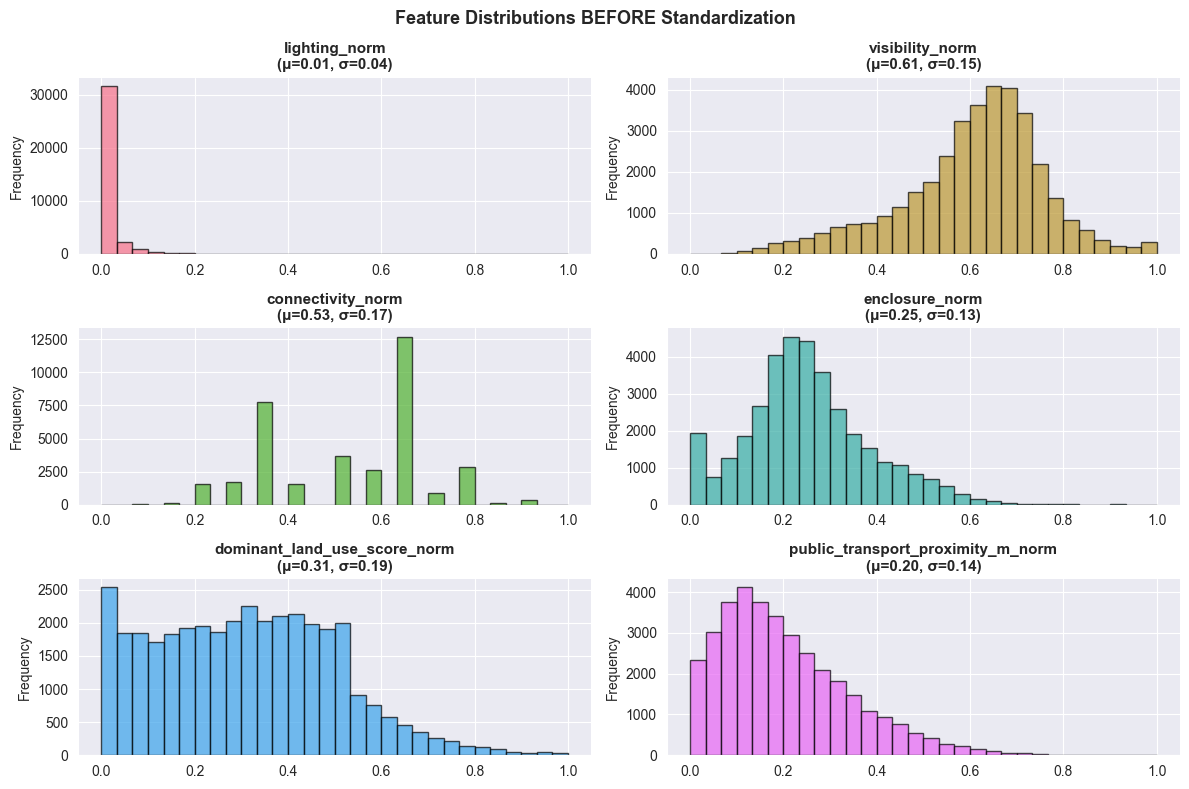

In [50]:
# Visualize feature distributions
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
colors_palette = sns.color_palette('husl', 6)

for ax, col, color in zip(axes.flat, FEATURE_COLS, colors_palette):
    ax.hist(X[col].dropna(), bins=30, color=color, edgecolor='black', alpha=0.7)
    ax.set_title(f'{col}\n(μ={X[col].mean():.2f}, σ={X[col].std():.2f})', fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency')
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Feature Distributions BEFORE Standardization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.2 Correlation Analysis

**Question:** Are any features highly correlated (redundant)?

In [51]:
# Compute correlation matrix
corr_matrix = X[FEATURE_COLS].corr()

print('Correlation Matrix:')
print(corr_matrix.round(3))

print('\nCorrelation Pairs (sorted by absolute value):')
# Extract upper triangle (avoid duplicates)
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        col1, col2 = corr_matrix.columns[i], corr_matrix.columns[j]
        corr_val = corr_matrix.loc[col1, col2]
        corr_pairs.append((col1, col2, corr_val))

corr_pairs_sorted = sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=True)
for col1, col2, corr_val in corr_pairs_sorted:
    print(f'  {col1:15s} ↔ {col2:15s}: {corr_val:7.3f}')

print('\nInterpretation:')
print('  |r| > 0.8  → Strong correlation (redundant features)')
print('  |r| 0.5-0.8 → Moderate correlation')
print('  |r| < 0.5  → Weak correlation (independent)')

Correlation Matrix:
                                   lighting_norm  visibility_norm  \
lighting_norm                             1.0000          -0.0030   
visibility_norm                          -0.0030           1.0000   
connectivity_norm                        -0.1110           0.0500   
enclosure_norm                           -0.0610          -0.7460   
dominant_land_use_score_norm              0.1030          -0.3620   
public_transport_proximity_m_norm        -0.1550           0.0570   

                                   connectivity_norm  enclosure_norm  \
lighting_norm                                -0.1110         -0.0610   
visibility_norm                               0.0500         -0.7460   
connectivity_norm                             1.0000          0.0090   
enclosure_norm                                0.0090          1.0000   
dominant_land_use_score_norm                 -0.1740          0.2280   
public_transport_proximity_m_norm             0.0750         -0.

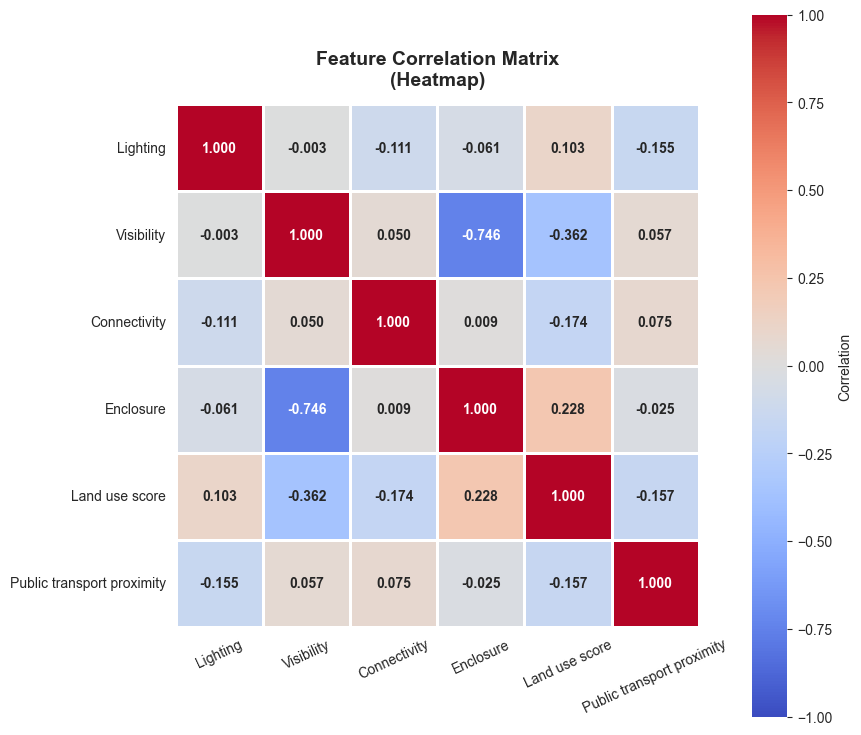

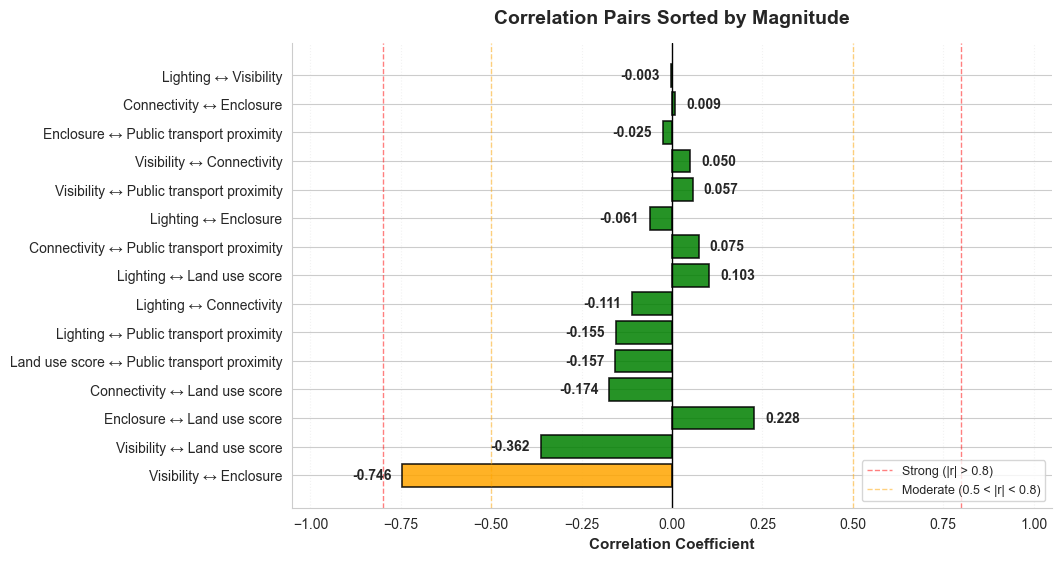

In [52]:
# Visualize correlations as separate readable plots
sns.set_style('whitegrid')

# Edit these display names manually if you want different labels in the plots
FEATURE_LABELS = {
    'lighting_norm': 'Lighting',
    'visibility_norm': 'Visibility',
    'connectivity_norm': 'Connectivity',
    'enclosure_norm': 'Enclosure',
    'dominant_land_use_score_norm': 'Land use score',
    'public_transport_proximity_m_norm': 'Public transport proximity'
}

clean_name = lambda name: FEATURE_LABELS.get(name, name.replace('_norm', ''))

# Plot 1: Correlation Heatmap
display_feature_names = [clean_name(col) for col in FEATURE_COLS]
corr_matrix_display = corr_matrix.copy()
corr_matrix_display.index = display_feature_names
corr_matrix_display.columns = display_feature_names

fig, ax = plt.subplots(figsize=(8.5, 7.5), constrained_layout=True)
sns.heatmap(
    corr_matrix_display,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=1,
    linecolor='white',
    cbar_kws={'label': 'Correlation'},
    annot_kws={'fontsize': 10, 'fontweight': 'bold'},
    ax=ax
 )
ax.set_title('Feature Correlation Matrix\n(Heatmap)', fontsize=14, fontweight='bold', pad=14)
ax.tick_params(axis='x', labelrotation=25, labelsize=10)
ax.tick_params(axis='y', labelrotation=0, labelsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.show()

# Plot 2: Correlation Pairs as Bar Chart
fig, ax = plt.subplots(figsize=(10.5, 5.5), constrained_layout=True)

pair_labels = [f'{clean_name(col1)} ↔ {clean_name(col2)}' for col1, col2, _ in corr_pairs_sorted]
pair_values = [val for _, _, val in corr_pairs_sorted]
colors = ['green' if abs(v) < 0.5 else 'orange' if abs(v) < 0.8 else 'red' for v in pair_values]

bars = ax.barh(
    range(len(pair_labels)),
    pair_values,
    color=colors,
    edgecolor='black',
    linewidth=1.2,
    alpha=0.85
 )
ax.set_yticks(range(len(pair_labels)))
ax.set_yticklabels(pair_labels, fontsize=10)
ax.set_xlabel('Correlation Coefficient', fontsize=11, fontweight='bold')
ax.set_title('Correlation Pairs Sorted by Magnitude', fontsize=14, fontweight='bold', pad=14)
ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax.axvline(x=0.8, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Strong (|r| > 0.8)')
ax.axvline(x=-0.8, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(x=0.5, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='Moderate (0.5 < |r| < 0.8)')
ax.axvline(x=-0.5, color='orange', linestyle='--', linewidth=1, alpha=0.5)
ax.grid(axis='x', alpha=0.25, linestyle=':')
ax.legend(fontsize=9, loc='lower right')
ax.spines[['top', 'right']].set_visible(False)

# Add value labels on bars
for i, val in enumerate(pair_values):
    x_pos = val + 0.03 if val > 0 else val - 0.03
    ha = 'left' if val > 0 else 'right'
    ax.text(x_pos, i, f'{val:.3f}', va='center', ha=ha, fontweight='bold', fontsize=10)

ax.set_xlim(-1.05, 1.05)
plt.show()

### 2.3 Variance Inflation Factor (VIF)

**Multicollinearity assessment:** VIF measures how much a feature's variance is inflated by its correlation with other features.
- VIF < 5: Low multicollinearity ✓
- VIF 5-10: Moderate multicollinearity ⚠
- VIF > 10: High multicollinearity ✗

In [53]:
# Standardize first (VIF calculation assumes scaled data)
scaler_temp = StandardScaler()
X_scaled_temp = scaler_temp.fit_transform(X[FEATURE_COLS])

# Calculate VIF for each feature
vif_data = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'VIF': [variance_inflation_factor(X_scaled_temp, i) for i in range(len(FEATURE_COLS))]
})

vif_data = vif_data.sort_values('VIF', ascending=False)

print('Variance Inflation Factor (VIF):')
print(vif_data.to_string(index=False))

print('\nInterpretation:')
for _, row in vif_data.iterrows():
    vif = row['VIF']
    if vif < 5:
        status = '✓ Low multicollinearity'
    elif vif < 10:
        status = '⚠ Moderate multicollinearity'
    else:
        status = '✗ High multicollinearity'
    print(f'  {row["Feature"]:15s}: {vif:6.2f}  {status}')

Variance Inflation Factor (VIF):
                          Feature    VIF
                  visibility_norm 2.4768
                   enclosure_norm 2.2873
     dominant_land_use_score_norm 1.2168
                    lighting_norm 1.0481
public_transport_proximity_m_norm 1.0476
                connectivity_norm 1.0448

Interpretation:
  visibility_norm:   2.48  ✓ Low multicollinearity
  enclosure_norm :   2.29  ✓ Low multicollinearity
  dominant_land_use_score_norm:   1.22  ✓ Low multicollinearity
  lighting_norm  :   1.05  ✓ Low multicollinearity
  public_transport_proximity_m_norm:   1.05  ✓ Low multicollinearity
  connectivity_norm:   1.04  ✓ Low multicollinearity


## Step 3: Standardization & PCA

In [54]:
# ====================================================================================
# STANDARDIZE FEATURES
# ====================================================================================
# PCA is sensitive to feature scaling; StandardScaler ensures each feature has
# mean=0, std=1 so high-variance features don't dominate the PCA.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[FEATURE_COLS])

# Verify scaling
X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURE_COLS)
print('Feature Statistics AFTER StandardScaler:')
print(X_scaled_df.describe().round(4))
print('\n✓ All features now have mean ≈ 0 and std ≈ 1')

Feature Statistics AFTER StandardScaler:
       lighting_norm  visibility_norm  connectivity_norm  enclosure_norm  \
count     35978.0000       35978.0000         35978.0000      35978.0000   
mean         -0.0000          -0.0000            -0.0000          0.0000   
std           1.0000           1.0000             1.0000          1.0000   
min          -0.3475          -3.9604            -3.1955         -1.9123   
25%          -0.3475          -0.4971            -1.0455         -0.6144   
50%          -0.3475           0.1532             0.2445         -0.0965   
75%          -0.1404           0.6379             0.6745          0.5347   
max          27.0854           2.5708             2.8244          5.6649   

       dominant_land_use_score_norm  public_transport_proximity_m_norm  
count                    35978.0000                         35978.0000  
mean                        -0.0000                             0.0000  
std                          1.0000                    

In [55]:
# ====================================================================================
# FIT PCA WITH ALL COMPONENTS
# ====================================================================================
# Don't specify n_components yet; fit with all to see the full picture.

pca_full = PCA()  # All components
X_pca_full = pca_full.fit_transform(X_scaled)

# Extract variance metrics
explained_variance_ratio = pca_full.explained_variance_ratio_
cumsum_explained = np.cumsum(explained_variance_ratio)

print('='*70)
print('PCA VARIANCE BREAKDOWN')
print('='*70)
for i in range(len(explained_variance_ratio)):
    pc_name = f'PC{i+1}'
    var_ratio = explained_variance_ratio[i]
    cum_ratio = cumsum_explained[i]
    bar_length = int(var_ratio * 50)  # Visual bar
    bar = '█' * bar_length + '░' * (50 - bar_length)
    print(f'{pc_name}: {var_ratio:6.1%} | {bar} | Cumulative: {cum_ratio:6.1%}')

print('\nSummary:')
print(f'  Total components: {len(explained_variance_ratio)}')
print(f'  90% variance explained by: {np.argmax(cumsum_explained >= 0.90) + 1} components')
print(f'  95% variance explained by: {np.argmax(cumsum_explained >= 0.95) + 1} components')

PCA VARIANCE BREAKDOWN
PC1:  32.7% | ████████████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ | Cumulative:  32.7%
PC2:  21.8% | ██████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ | Cumulative:  54.5%
PC3:  15.6% | ███████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ | Cumulative:  70.2%
PC4:  13.9% | ██████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ | Cumulative:  84.1%
PC5:  11.9% | █████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ | Cumulative:  96.0%
PC6:   4.0% | █░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ | Cumulative: 100.0%

Summary:
  Total components: 6
  90% variance explained by: 5 components
  95% variance explained by: 5 components


### Scree Plot & Cumulative Variance

**Scree plot:** Shows how much variance each PC captures. Look for the "elbow" where diminishing returns begin.

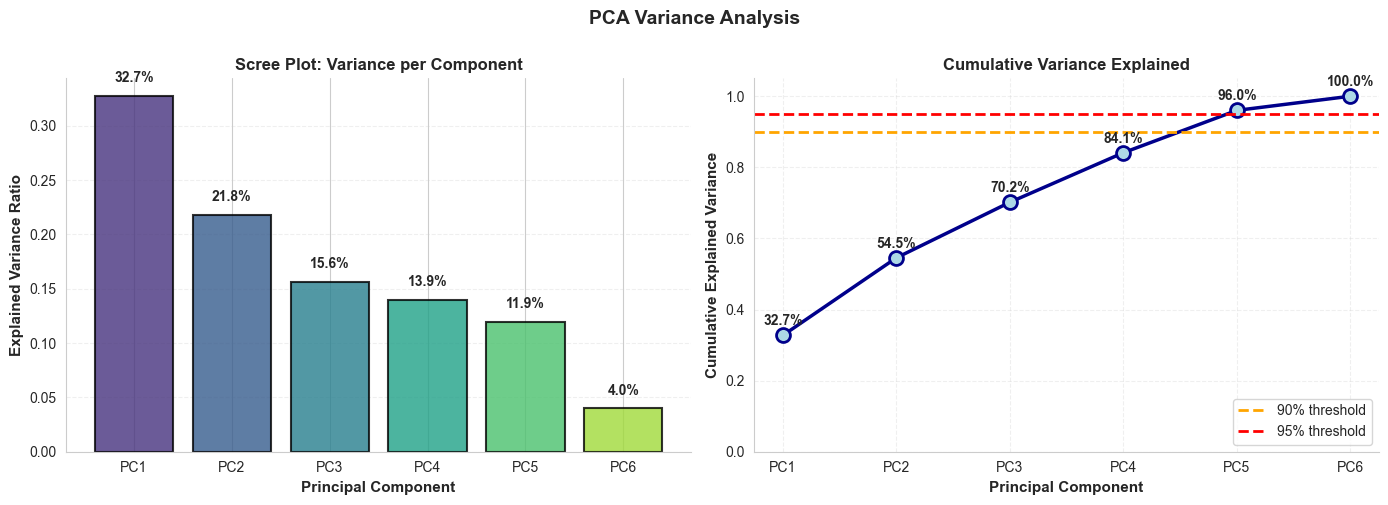

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Individual variance per PC
ax1 = axes[0]
pc_labels = [f'PC{i+1}' for i in range(len(explained_variance_ratio))]
colors_bar = sns.color_palette('viridis', len(explained_variance_ratio))
ax1.bar(pc_labels, explained_variance_ratio, color=colors_bar, edgecolor='black', linewidth=1.5, alpha=0.8)
ax1.set_ylabel('Explained Variance Ratio', fontsize=11, fontweight='bold')
ax1.set_xlabel('Principal Component', fontsize=11, fontweight='bold')
ax1.set_title('Scree Plot: Variance per Component', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.spines[['top', 'right']].set_visible(False)

# Add value labels on bars
for i, (pc, var) in enumerate(zip(pc_labels, explained_variance_ratio)):
    ax1.text(i, var + 0.01, f'{var:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Plot 2: Cumulative variance
ax2 = axes[1]
ax2.plot(pc_labels, cumsum_explained, 'o-', linewidth=2.5, markersize=10, 
         color='darkblue', markerfacecolor='lightblue', markeredgewidth=2, markeredgecolor='darkblue')
ax2.axhline(y=0.90, color='orange', linestyle='--', linewidth=2, label='90% threshold')
ax2.axhline(y=0.95, color='red', linestyle='--', linewidth=2, label='95% threshold')
ax2.set_ylabel('Cumulative Explained Variance', fontsize=11, fontweight='bold')
ax2.set_xlabel('Principal Component', fontsize=11, fontweight='bold')
ax2.set_title('Cumulative Variance Explained', fontsize=12, fontweight='bold')
ax2.set_ylim([0, 1.05])
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(fontsize=10, loc='lower right')
ax2.spines[['top', 'right']].set_visible(False)

# Add cumulative values on points
for i, (pc, cum) in enumerate(zip(pc_labels, cumsum_explained)):
    ax2.text(i, cum + 0.02, f'{cum:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.suptitle('PCA Variance Analysis', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### PCA Loadings: Which Original Features Drive Each PC?

In [57]:
# Extract loadings (components)
loadings = pd.DataFrame(
    pca_full.components_,
    columns=FEATURE_COLS,
    index=[f'PC{i+1}' for i in range(len(pca_full.components_))]
)

print('='*70)
print('PCA LOADINGS (Contribution of original features to each PC)')
print('='*70)
print(loadings.round(4))

print('\n' + '='*70)
print('INTERPRETATION GUIDE')
print('='*70)
for i, (pc_name, row) in enumerate(loadings.iterrows()):
    print(f'\n{pc_name} (explains {explained_variance_ratio[i]:.1%} of variance):')
    row_sorted = row.abs().sort_values(ascending=False)
    for feat, loading_abs in row_sorted.items():
        loading_actual = row[feat]
        sign = '+' if loading_actual > 0 else '−'
        magnitude = 'Strong' if loading_abs > 0.6 else 'Moderate' if loading_abs > 0.4 else 'Weak'
        print(f'  {feat:15s}: {sign} {loading_abs:.3f} ({magnitude})')

PCA LOADINGS (Contribution of original features to each PC)
     lighting_norm  visibility_norm  connectivity_norm  enclosure_norm  \
PC1        -0.0471           0.6431             0.1228         -0.6003   
PC2         0.5737           0.1736            -0.4731         -0.2872   
PC3         0.2559          -0.0284             0.7677          0.0705   
PC4         0.7729          -0.1028             0.1388          0.0959   
PC5        -0.0661           0.1365             0.3900         -0.2988   
PC6         0.0365           0.7254            -0.0194          0.6735   

     dominant_land_use_score_norm  public_transport_proximity_m_norm  
PC1                       -0.4343                             0.1417  
PC2                        0.2960                            -0.4968  
PC3                       -0.1351                            -0.5667  
PC4                       -0.1379                             0.5870  
PC5                        0.8174                             0.25

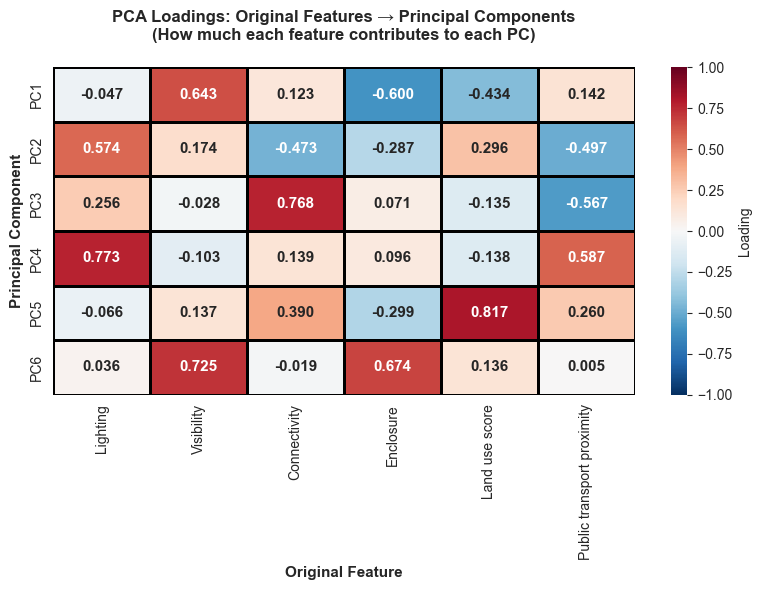

In [58]:
# Visualize loadings as heatmap
loadings_display = loadings.copy()
loadings_display.columns = [clean_name(col) for col in loadings.columns]

plt.figure(figsize=(8, 6))
sns.heatmap(loadings_display, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1, fmt='.3f',
            cbar_kws={'label': 'Loading'}, linewidths=1, linecolor='black', 
            annot_kws={'fontsize': 11, 'fontweight': 'bold'})
plt.title('PCA Loadings: Original Features → Principal Components\n(How much each feature contributes to each PC)', 
          fontsize=12, fontweight='bold', pad=20)
plt.ylabel('Principal Component', fontsize=11, fontweight='bold')
plt.xlabel('Original Feature', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

### PC1 vs PC2 Biplot

**Biplot shows:**
- **Points:** Samples projected onto PC1 & PC2, colored by safety class
- **Arrows:** Original feature vectors showing their contribution to PC1 & PC2

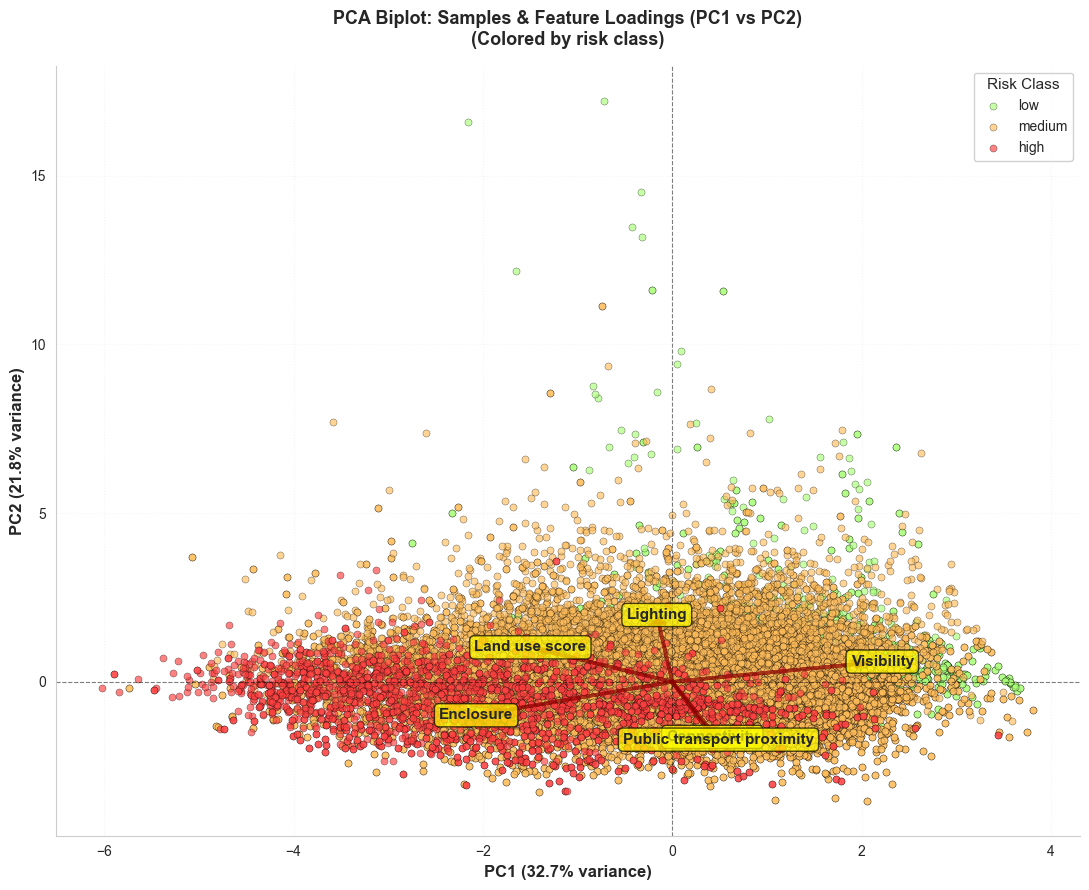

In [59]:
# Prepare biplot data
biplot_df = pd.DataFrame(
    X_pca_full[:, :2],
    columns=['PC1', 'PC2']
 )

# Derive risk_class from numeric `risk_score` (always use numeric score, ignore any existing risk_class)
risk_numeric = pd.to_numeric(features.loc[X.index, 'risk_score'], errors='coerce').reset_index(drop=True)
biplot_df['risk_class'] = pd.cut(
    risk_numeric,
    bins=[-np.inf, 0.33, 0.66, np.inf],
    labels=['low', 'medium', 'high'],
    include_lowest=True
).astype(str)

# Create biplot
fig, ax = plt.subplots(figsize=(11, 9))

# Plot samples by class
colors_map = {'low': '#AAFF79', 'medium': '#FFBD5B', 'high': '#FF4040'}
for risk_level in ['low', 'medium', 'high']:
    mask = biplot_df['risk_class'] == risk_level
    ax.scatter(
        biplot_df.loc[mask, 'PC1'],
        biplot_df.loc[mask, 'PC2'],
        label=risk_level,
        color=colors_map.get(risk_level, 'gray'),
        alpha=0.65,
        s=26,
        edgecolors='black',
        linewidth=0.3,
        zorder=1
    )

# Plot loading vectors (arrows)
arrow_scale = 3  # Adjust for visibility
loadings_2pc = pca_full.components_[:2, :]

for i, feature in enumerate(FEATURE_COLS):
    ax.arrow(
        0, 0,
        arrow_scale * loadings_2pc[0, i],
        arrow_scale * loadings_2pc[1, i],
        head_width=0.15,
        head_length=0.15,
        fc='red',
        ec='darkred',
        alpha=0.7,
        linewidth=2.5,
        zorder=3
    )

    # Label arrows
    ax.text(
        arrow_scale * loadings_2pc[0, i] * 1.15,
        arrow_scale * loadings_2pc[1, i] * 1.15,
        clean_name(feature),
        fontsize=11,
        fontweight='bold',
        ha='center',
        va='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7, edgecolor='black'),
        zorder=4
    )

# Formatting
ax.axhline(y=0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(x=0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
ax.grid(True, alpha=0.2, linestyle=':')

ax.set_xlabel(f'PC1 ({explained_variance_ratio[0]:.1%} variance)', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({explained_variance_ratio[1]:.1%} variance)', fontsize=12, fontweight='bold')
ax.set_title('PCA Biplot: Samples & Feature Loadings (PC1 vs PC2)\n(Colored by risk class)', 
             fontsize=13, fontweight='bold', pad=15)
ax.legend(title='Risk Class', fontsize=10, title_fontsize=11, loc='best', framealpha=0.9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### Feature Interaction Analysis

**Pairplot:** Visualize relationships between features, colored by safety class.

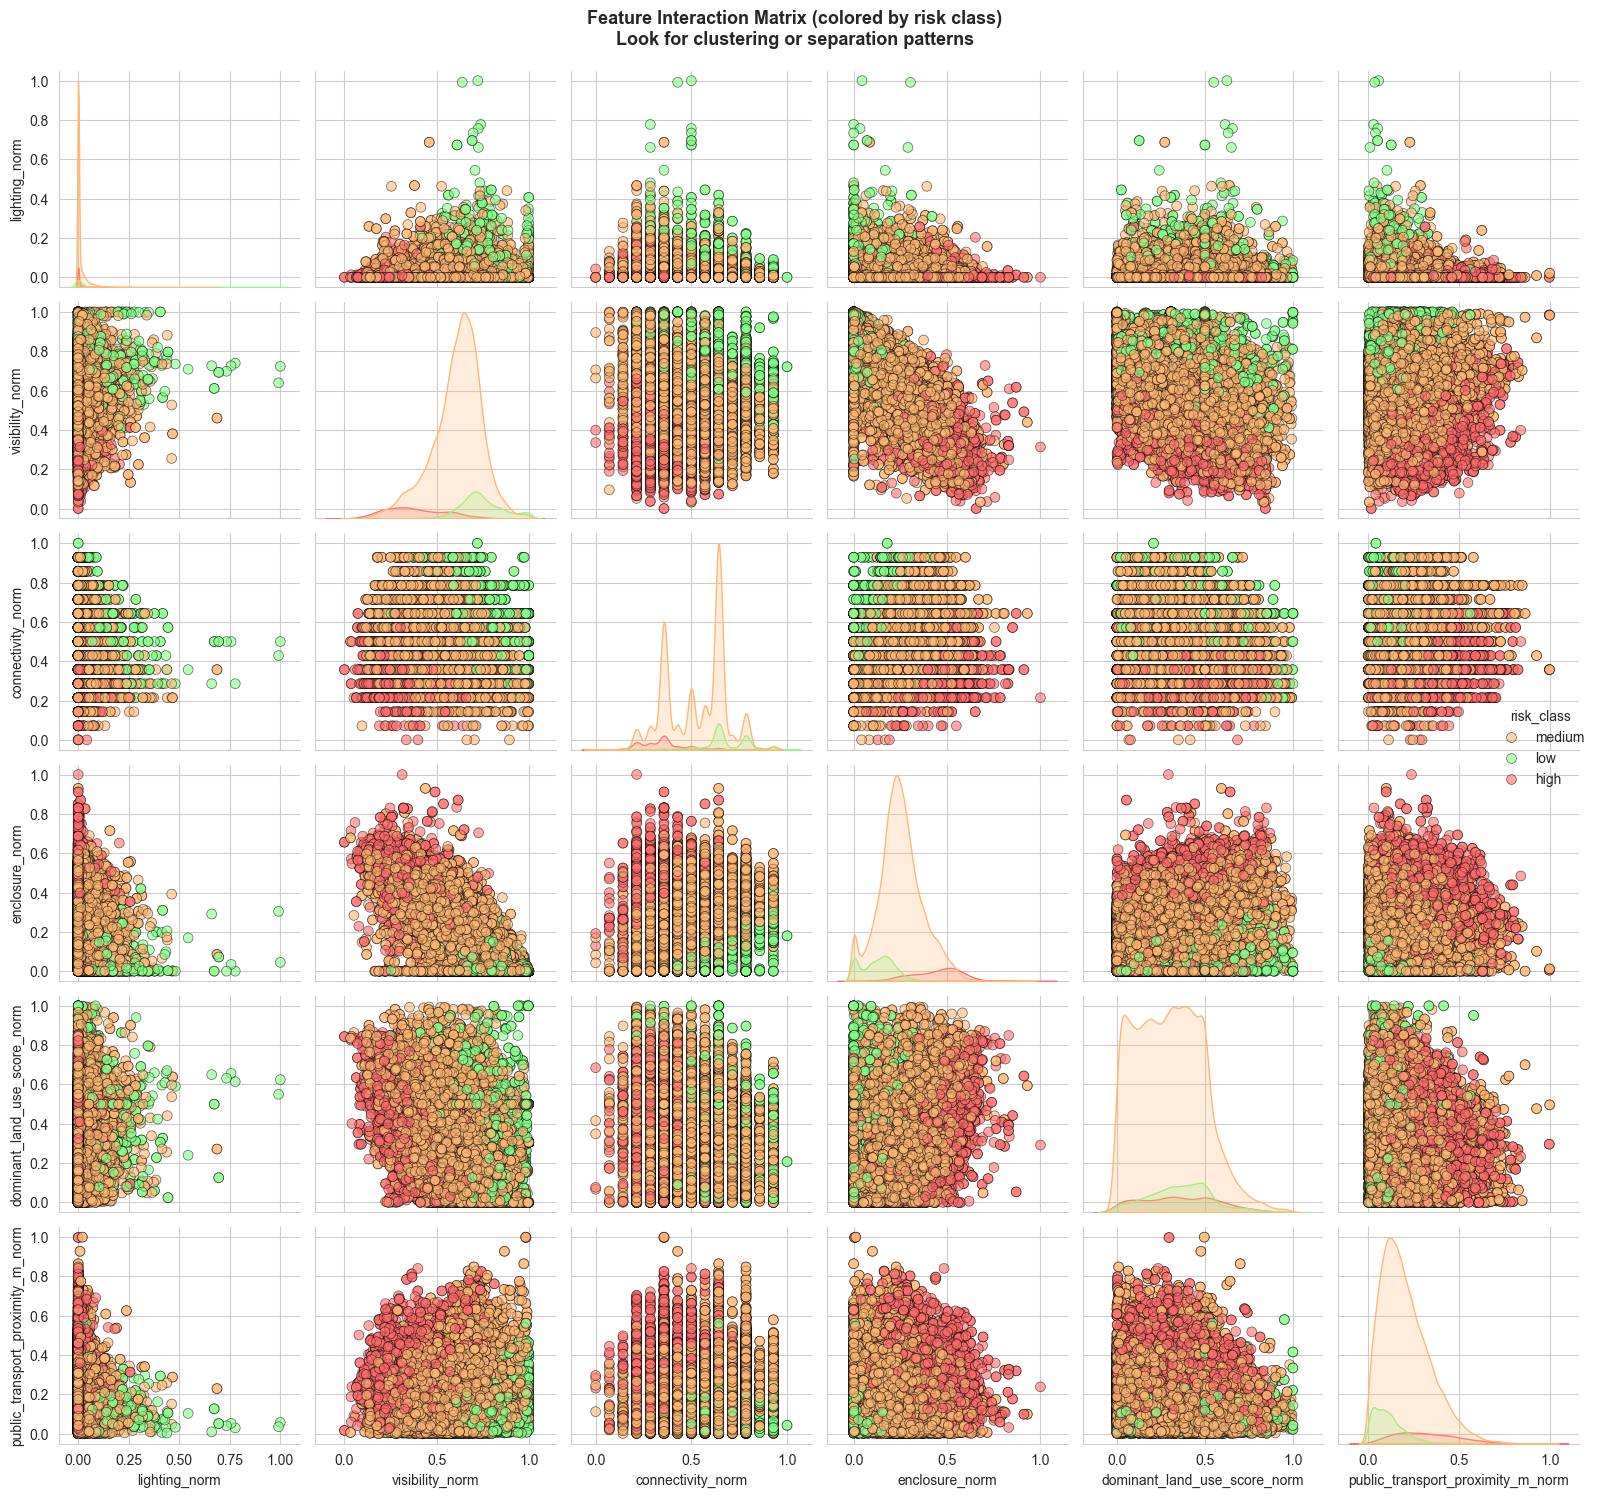

In [60]:
# Create pairplot
pairplot_df = X[FEATURE_COLS].copy().reset_index(drop=True)

# Derive display classes from the numeric risk score (always use risk_score)
risk_numeric = pd.to_numeric(features.loc[X.index, 'risk_score'], errors='coerce').reset_index(drop=True)
pairplot_df['risk_class'] = pd.cut(
    risk_numeric,
    bins=[-np.inf, 0.33, 0.66, np.inf],
    labels=['low', 'medium', 'high'],
    include_lowest=True
).astype(str)

pairplot = sns.pairplot(
    pairplot_df,
    hue='risk_class',
    palette={'low': "#85FF89", 'medium': "#FFB774", 'high': "#FF6C6C"},
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 50, 'edgecolor': 'k', 'linewidth': 0.5},
    height=2.5
)

pairplot.fig.suptitle('Feature Interaction Matrix (colored by risk class)\nLook for clustering or separation patterns', 
                       fontsize=13, fontweight='bold', y=0.995)
pairplot.fig.tight_layout()